# Exploratory Data Analysis: Wine Reviews Dataset

### Датасет содержит отзывы о винах, включая:

- страну происхождения
- регион
- сорт винограда
- цену
- оценку вина (points)
- описание от дегустаторов

### Источник датасета:
https://www.kaggle.com/datasets/zynicide/wine-reviews

### Размер датасета:
- ~130k записей
- 14 признаков

### Цель анализа:
провести разведочный анализ данных (EDA), очистить данные, исследовать зависимости и подготовить данные для дальнейшего машинного обучения.


In [3]:
import pandas as pd

wine_df = pd.read_csv('winemag-data-130k-v2.csv', index_col=0)

wine_df.info()
wine_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  str    
 1   description            129971 non-null  str    
 2   designation            92506 non-null   str    
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  str    
 6   region_1               108724 non-null  str    
 7   region_2               50511 non-null   str    
 8   taster_name            103727 non-null  str    
 9   taster_twitter_handle  98758 non-null   str    
 10  title                  129971 non-null  str    
 11  variety                129970 non-null  str    
 12  winery                 129971 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 12.9 MB


(129971, 13)

В датасете 129971 строк и 14 колонок.
В датасете присутствуют:

Числовые признаки:
- points
- price

Категориальные признаки:
- country
- province
- variety
- winery
- taster_name

Также видно, что некоторые признаки имеют пропуски:
- price
- designation
- region_1
- region_2
- taster_name

In [4]:
display(wine_df.head())
display(wine_df.tail())

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss
129970,France,"Big, rich and off-dry, this is powered by inte...",Lieu-dit Harth Cuvée Caroline,90,21.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Schoffit 2012 Lieu-dit Harth Cuvée Car...,Gewürztraminer,Domaine Schoffit


In [5]:
wine_df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


In [6]:
wine_df.describe(include=['object', 'string'])

,country,description,designation,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,129908,129971,92506,129908,108724,50511,103727,98758,129971,129970,129971
unique,43,119955,37979,425,1229,17,19,15,118840,707,16757
top,US,This zesty red has pretty aromas that suggest ...,Reserve,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,54504,3,2009,36247,4480,11065,25514,25514,11,13272,222


In [7]:
wine_df.isnull().sum().sort_values(ascending=False)

region_2                 79460
designation              37465
taster_twitter_handle    31213
taster_name              26244
region_1                 21247
price                     8996
province                    63
country                     63
variety                      1
points                       0
description                  0
title                        0
winery                       0
dtype: int64

Некоторые признаки имеют значительное количество пропусков:

- region_2
- designation
- taster_twitter_handle
- taster_name
- region_1
- price

Это потребует обработки на этапе очистки данных.

In [8]:
wine_df.duplicated().sum()

np.int64(9983)

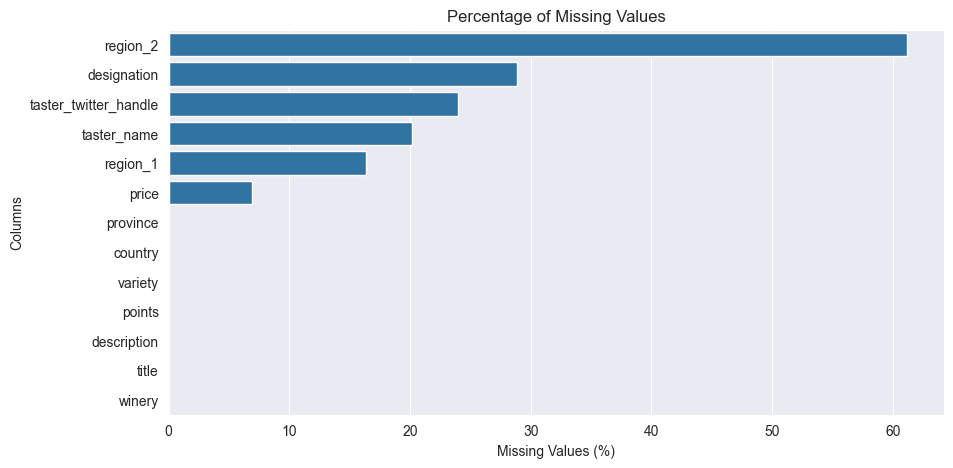

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_percent = wine_df.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.title("Percentage of Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")

plt.show()

In [10]:
wine_df = wine_df.dropna(subset=["country", "province", "variety"])

wine_df["price"] = wine_df["price"].fillna(wine_df["price"].median())

wine_df["taster_name"] = wine_df["taster_name"].fillna("Unknown")

wine_df["taster_twitter_handle"] = wine_df["taster_twitter_handle"].fillna(
    wine_df["taster_twitter_handle"].mode()[0]
)

wine_df = wine_df.drop(columns=["region_2"])

wine_df["region_1"] = wine_df["region_1"].fillna(wine_df["region_1"].mode()[0])
wine_df["designation"] = wine_df["designation"].fillna(wine_df["designation"].mode()[0])

# Проверяем результат
wine_df.isnull().sum()

country                  0
description              0
designation              0
points                   0
price                    0
province                 0
region_1                 0
taster_name              0
taster_twitter_handle    0
title                    0
variety                  0
winery                   0
dtype: int64

Колонки `country`, `province` и `variety` содержат очень небольшое количество пропусков 
(менее 0.1% от датасета). Удаление этих строк практически не влияет на общий объем данных, 
поэтому для них была применена стратегия `dropna()`.

Колонка `price` содержит числовые значения и имеет выбросы 
(некоторые вина стоят значительно дороже остальных).
Для таких распределений медиана является более устойчивой 
оценкой центрального значения, чем среднее. Поэтому пропуски 
в колонке `price` были заполнены медианой.

Колонка `taster_name` содержит имена дегустаторов. 
Пропуски были заполнены строкой `"Unknown"`, чтобы сохранить 
данные и явно обозначить отсутствие информации о дегустаторе.

In [11]:
stats = wine_df[['price', 'points']].agg(['min', 'max', 'mean', 'median'])
stats.loc['mode'] = wine_df[['price', 'points']].mode().iloc[0]

display(stats)

quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

quantiles_df = pd.DataFrame({
    "price": wine_df["price"].quantile(quantiles),
    "points": wine_df["points"].quantile(quantiles)
})

display(quantiles_df)


stats = wine_df[['price', 'points']].agg(['var', 'skew', 'kurtosis']).T
stats.columns = ['Variance', 'Skewness', 'Kurtosis']
display(stats)

,price,points
min,4.000000,80.000000
max,3300.000000,100.000000
mean,34.651081,88.447051
median,25.000000,88.000000
mode,25.000000,88.000000


,price,points
0.05,11.0,84.0
0.25,18.0,86.0
0.50,25.0,88.0
0.75,40.0,91.0
0.95,80.0,93.0


,Variance,Skewness,Kurtosis
price,1573.950468,18.584938,884.571498
points,9.242071,0.046095,-0.296326


## Интерпретация дисперсии, асимметрии и эксцесса

### Points

- **Дисперсия (variance) = 9.24** — разброс оценок очень небольшой.
  Большинство вин получают оценки в узком диапазоне, эксперты редко ставят экстремальные баллы.

- **Асимметрия (skewness) = 0.046** — распределение практически **симметричное**.
  Значение близко к 0, значит оценки распределены равномерно вокруг среднего — почти как нормальное распределение.

- **Эксцесс (kurtosis) = -0.296** — распределение слегка **платикуртическое** (плоское).
  Хвосты чуть тоньше, чем у нормального распределения, пик более сглаженный.
  Это значит, что очень высокие и очень низкие оценки встречаются чуть реже, чем ожидалось бы.

> **Вывод:** `points` — хорошо себя ведущая числовая переменная без серьёзных аномалий.
> Подходит для моделирования практически без дополнительных преобразований.

---

### Price

- **Дисперсия (variance) = 1573.95** — огромный разброс цен.
  Среди вин есть как бюджетные варианты, так и элитные бутылки за тысячи долларов.

- **Асимметрия (skewness) = 18.58** — экстремально **правосторонняя асимметрия**.
  Подавляющее большинство вин стоит дёшево, но длинный «хвост» из очень дорогих бутылок
  сильно тянет среднее вверх. Медиана здесь намного репрезентативнее среднего.

- **Эксцесс (kurtosis) = 884.57** — экстремально **лептокуртическое** (остроконечное) распределение.
  Значение в сотни раз выше нормального (норма ≈ 0 по excess kurtosis).
  Это прямо указывает на наличие **выбросов-экстремумов**: несколько вин с астрономической ценой
  кардинально отличаются от основной массы.

>  **Вывод:** `price` требует обработки перед моделированием:
> - Применить **log-преобразование** (`np.log1p(price)`), чтобы «сжать» хвост
> - Или **обрезать выбросы** по перцентилям (например, оставить до 99-го перцентиля)

In [12]:
wine_df.nunique()

country                      43
description              119895
designation               37954
points                       21
price                       390
province                    425
region_1                   1229
taster_name                  20
taster_twitter_handle        15
title                    118780
variety                     701
winery                    16745
dtype: int64

In [13]:
country_encoded = pd.get_dummies(wine_df['country'], prefix='country')
wine_df_encoded = pd.concat([wine_df, country_encoded], axis=1)
wine_df_encoded.head()

,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,...,country_Serbia,country_Slovakia,country_Slovenia,country_South Africa,country_Spain,country_Switzerland,country_Turkey,country_US,country_Ukraine,country_Uruguay
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,25.0,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),...,False,False,False,False,False,False,False,False,False,False
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,Napa Valley,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),...,False,False,False,False,False,False,False,False,False,False
2,US,"Tart and snappy, the flavors of lime flesh and...",Reserve,87,14.0,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),...,False,False,False,False,False,False,False,True,False,False
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,Alexander Peartree,@vossroger,St. Julian 2013 Reserve Late Harvest Riesling ...,...,False,False,False,False,False,False,False,True,False,False
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,...,False,False,False,False,False,False,False,True,False,False


In [14]:
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=10, input_type='string')
hashed_features = hasher.transform(
    wine_df['winery'].astype(str).apply(lambda x: [x])
)
hashed_df = pd.DataFrame(hashed_features.toarray())

hashed_df.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
import re

yearSearch = []    
for value in wine_df['title']:
    regex_result = re.search(r'19\d{2}|20\d{2}', value)
    if regex_result:
        yearSearch.append(regex_result.group())
    else: 
        yearSearch.append(None)

wine_df['year'] = yearSearch
wine_df['year'] = wine_df['year'].astype('Int64')

#Tell me which ones don't have a year listed
print("We extracted %d years from the wine titles and %d did not have a year." %(len(wine_df[wine_df['year'].notna()]), len(wine_df[wine_df['year'].isna()].index)))
wine_df['year'].describe()

We extracted 125283 years from the wine titles and 4624 did not have a year.


count      125283.0
mean     2010.66966
std        3.797799
min          1904.0
25%          2009.0
50%          2011.0
75%          2013.0
max          2017.0
Name: year, dtype: Float64

In [16]:
# Считаем сколько раз встречается каждый сорт
variety_counts = wine_df['variety'].value_counts()

# Разбиваем сорта по перцентилям
wine_df['rarity_category'] = pd.qcut(wine_df['variety'].map(variety_counts),
                                  q=4,
                                  labels=['rare', 'niche', 'popular', 'mainstream'],
                                  duplicates='drop')  # на случай одинаковых границ

wine_df.head()

,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,variety,winery,year,rarity_category
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,25.0,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,2013,niche
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,Napa Valley,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,2011,niche
2,US,"Tart and snappy, the flavors of lime flesh and...",Reserve,87,14.0,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,2013,niche
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,Alexander Peartree,@vossroger,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,2013,popular
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,2012,mainstream


## Визуализация данных

### 1. Распределение оценок (Points)

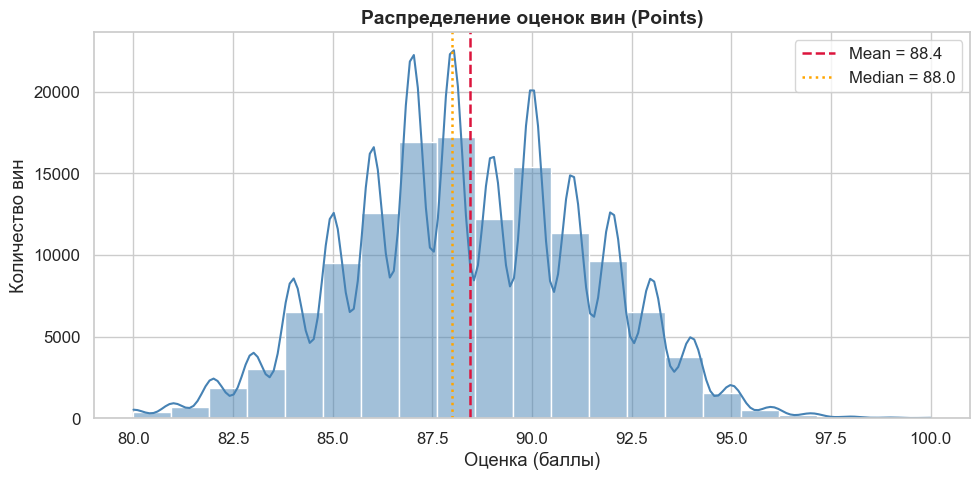

In [17]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
df_viz = wine_df[wine_df['price'] < wine_df['price'].quantile(0.95)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(wine_df['points'], bins=21, kde=True, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(wine_df['points'].mean(), color='crimson', linestyle='--', linewidth=1.8,
           label=f'Mean = {wine_df["points"].mean():.1f}')
ax.axvline(wine_df['points'].median(), color='orange', linestyle=':', linewidth=1.8,
           label=f'Median = {wine_df["points"].median():.1f}')
ax.set_title('Распределение оценок вин (Points)', fontsize=14, fontweight='bold')
ax.set_xlabel('Оценка (баллы)')
ax.set_ylabel('Количество вин')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод:** Оценки распределены практически нормально с центром около 88 баллов. 
Среднее и медиана почти совпадают, что говорит об отсутствии выбросов в этом признаке.
Шкала оценок фактически работает в диапазоне 80–100 — вина ниже 80 баллов в датасет не включают.
Это создаёт **левостороннее отсечение**: плохих вин в данных просто нет, что нужно учитывать при обучении модели.

### 2. Распределение цены: сырые данные vs log-преобразование

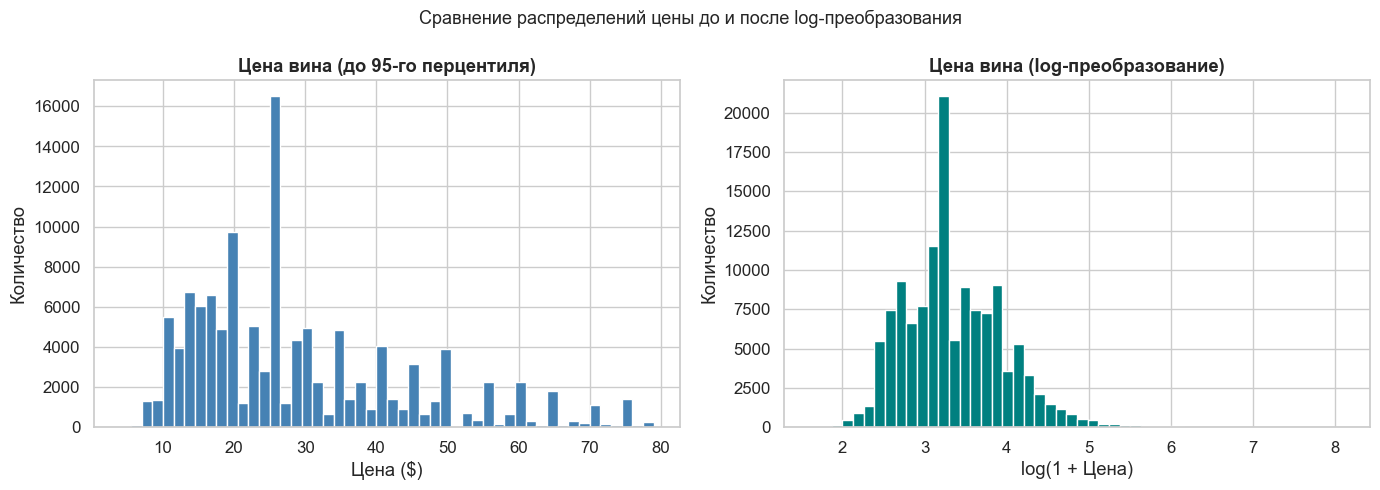

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_viz['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Цена вина (до 95-го перцентиля)', fontweight='bold')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Количество')

axes[1].hist(np.log1p(wine_df['price']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Цена вина (log-преобразование)', fontweight='bold')
axes[1].set_xlabel('log(1 + Цена)')
axes[1].set_ylabel('Количество')

plt.suptitle('Сравнение распределений цены до и после log-преобразования', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** В сыром виде распределение цен экстремально скошено вправо — большинство вин стоит до \$50,
но длинный хвост (элитные вина) сильно искажает масштаб.
После log-преобразования распределение становится близким к нормальному,
что значительно улучшит работу большинства ML-алгоритмов.

### 3. Средняя оценка вин по странам (топ-10 по количеству)

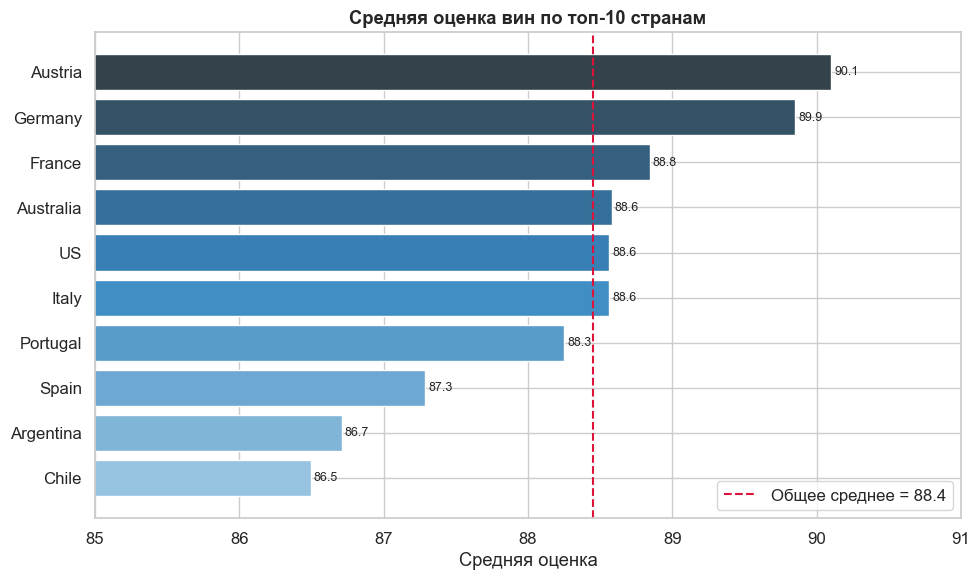

In [19]:
top_countries = wine_df['country'].value_counts().head(10).index
country_stats = (wine_df[wine_df['country'].isin(top_countries)]
                 .groupby('country')['points']
                 .agg(['mean', 'count'])
                 .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_stats.index, country_stats['mean'],
               color=sns.color_palette('Blues_d', len(country_stats)))
ax.axvline(wine_df['points'].mean(), color='crimson', linestyle='--',
           linewidth=1.5, label=f'Общее среднее = {wine_df["points"].mean():.1f}')
ax.set_xlabel('Средняя оценка')
ax.set_xlim(85, 91)
ax.set_title('Средняя оценка вин по топ-10 странам', fontweight='bold')
for bar, (_, row) in zip(bars, country_stats.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.1f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

**Вывод:** Среди самых представленных в датасете стран лидируют по качеству **Австрия** и **Германия** — 
несмотря на то что они производят значительно меньше вин, чем США и Франция.
США, доминируя по количеству (>54k записей), показывают среднюю оценку около 88.6, что чуть выше общего среднего.
Чили и Аргентина замыкают рейтинг, хотя разрыв между всеми странами невелик (≈3.6 балла).
**Вывод для модели:** признак `country` несёт полезный сигнал и стоит включить его после кодирования.

### 4. Связь между ценой и оценкой

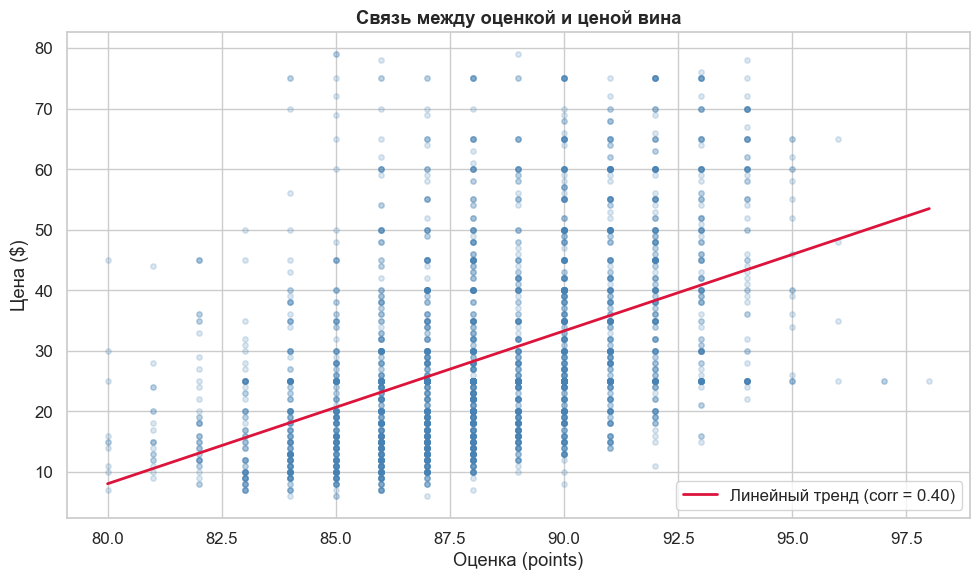

In [20]:
sample = df_viz.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['points'], sample['price'], alpha=0.2, s=15, color='steelblue')

m, b = np.polyfit(sample['points'], sample['price'], 1)
x_line = np.linspace(sample['points'].min(), sample['points'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        label=f'Линейный тренд (corr = {wine_df["price"].corr(wine_df["points"]):.2f})')

ax.set_xlabel('Оценка (points)')
ax.set_ylabel('Цена ($)')
ax.set_title('Связь между оценкой и ценой вина', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод:** Корреляция между оценкой и ценой составляет **r ≈ 0.40** — связь умеренная и положительная.
Более высокооценённые вина в среднем стоят дороже, но разброс очень большой:
есть дорогие вина с низкими оценками и наоборот.
Это означает, что цена является **полезным, но не определяющим** признаком для предсказания качества.
При моделировании оба признака стоит использовать независимо.

### 5. Оценка и цена по редкости сорта винограда

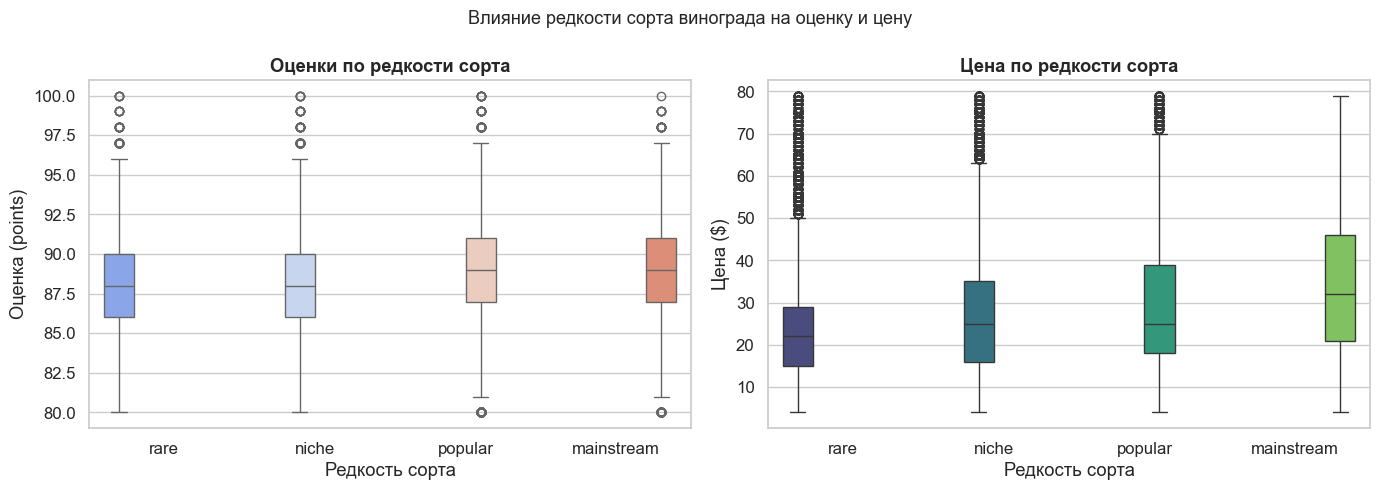

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['rare', 'niche', 'popular', 'mainstream']

sns.boxplot(data=wine_df, x='rarity_category', y='points', order=order,
            hue='rarity_category', legend=False, palette='coolwarm', ax=axes[0])
axes[0].set_title('Оценки по редкости сорта', fontweight='bold')
axes[0].set_xlabel('Редкость сорта')
axes[0].set_ylabel('Оценка (points)')

sns.boxplot(data=df_viz, x='rarity_category', y='price', order=order,
            hue='rarity_category', legend=False, palette='viridis', ax=axes[1])
axes[1].set_title('Цена по редкости сорта', fontweight='bold')
axes[1].set_xlabel('Редкость сорта')
axes[1].set_ylabel('Цена ($)')

plt.suptitle('Влияние редкости сорта винограда на оценку и цену', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** Оценки практически не зависят от редкости сорта — медианы всех категорий близки. По цене массовые сорта (mainstream) в среднем стоят дороже редких, что может объясняться тем, что популярные сорта (Pinot Noir, Chardonnay) часто относятся к премиальным брендам.

### 6. Матрица корреляций числовых признаков

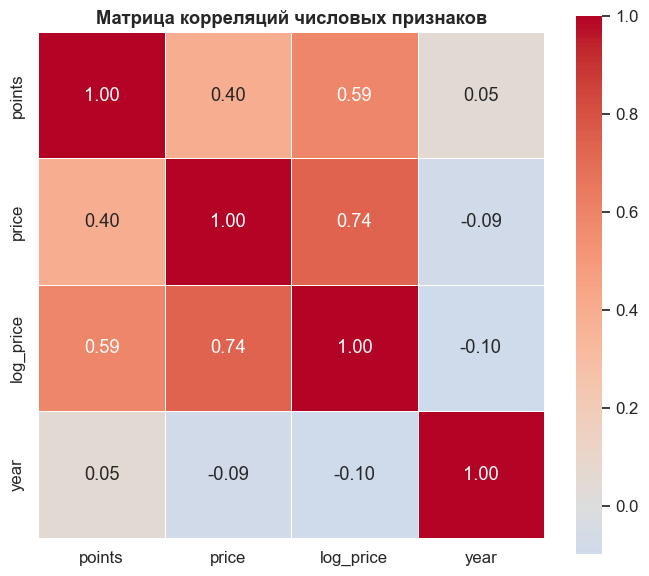

In [22]:
wine_df['log_price'] = np.log1p(wine_df['price'])

corr_df = wine_df[['points', 'price', 'log_price', 'year']].dropna()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Матрица корреляций числовых признаков', fontweight='bold')
plt.tight_layout()
plt.show()

**Вывод:**
- points и log_price коррелируют сильнее (0.59), чем points и сырая price (0.40) — это подтверждает, что log-преобразование делает связь более линейной. В модели лучше использовать log_price.
- price и log_price коррелируют на 0.74 — это ниже, чем ожидалось бы от монотонного преобразования, и говорит о том, что log действительно сильно меняет распределение (сжимает хвост с дорогими винами). Тем не менее использовать оба признака одновременно не стоит — они несут похожую информацию.
- year почти не коррелирует ни с чем (0.05 с оценкой, -0.09 и -0.10 с ценой) — год урожая не является полезным числовым признаком в текущем виде и вряд ли улучшит модель.

In [24]:
import plotly.express as px

fig = px.scatter(
    df_viz.sample(3000, random_state=42),
    x='points', y='price',
    color='country',
    hover_data=['variety', 'winery'],
    title='Оценка vs Цена (интерактивный график)',
    labels={'points': 'Оценка', 'price': 'Цена ($)'}
)
fig.show()

**Вывод:** График подтверждает умеренную положительную связь между оценкой и ценой — с ростом баллов облако точек постепенно смещается вверх. При этом разброс цен на каждом уровне оценки очень большой: например, при 90 баллах вина стоят и $15, и $80. Это значит, что оценка объясняет цену лишь частично.
По странам видно, что американские вина (оранжевые, US) доминируют по всему диапазону оценок и цен — просто потому что их в датасете больше всего. Французские и итальянские вина чаще встречаются в верхней части ценового диапазона при высоких оценках, что согласуется с их репутацией премиальных производителей.

## Итоговые выводы

### Что я поняла про датасет

- Все оценки от 80 баллов и выше, плохие вина сюда просто не попали. Модель, обученная на этих данных, будет работать только в диапазоне «хороших» вин
- Больше 40% записей — американские вина, датасет заметно смещён в сторону США
- Оценки распределены почти нормально около 88 баллов, но на графике заметны пики на круглых числах — дегустаторы чуть чаще ставят 87, 88, 89, 90, чем промежуточные значения
- Цена распределена очень неравномерно: медиана ~$25, но есть вина за тысячи долларов. Log-преобразование делает распределение пригодным для моделирования
- Корреляция оценки с log_price (0.59) заметно выше, чем с сырой ценой (0.40) — это подтверждает, что в модели лучше использовать преобразованный признак
- Австрия и Германия дают лучшие средние оценки среди топ-10 стран, хотя представлены куда меньше США и Франции
- Год урожая почти не коррелирует ни с оценкой, ни с ценой — как числовой признак он малополезен
- Несколько дегустаторов отвечают за большую часть отзывов (Roger Voss — 25k+), что вносит субъективное смещение в оценки
- Оценки практически не зависят от редкости сорта — медианы всех категорий близки, несмотря на интуитивное ожидание обратного
- Популярные сорта (Pinot Noir, Chardonnay) стоят в среднем дороже редких — скорее из-за бренда, чем из-за качества

### Гипотезы

1. **Австрия и Германия получают высокие оценки**, вероятно, потому что на международный рынок из этих стран попадает только отборное вино — в отличие от США, где объём огромный и качество более размытое
2. **Дегустатор, скорее всего, влияет на оценку не меньше, чем само вино** — у каждого свои предпочтения и своя шкала
3. **Дорогое вино ≠ хорошее вино:** при corr=0.40 цена объясняет лишь ~16% разброса в оценках, значит за ценой стоит что-то ещё — бренд, регион, маркетинг
4. **Выбросы по цене скорее всего коллекционные позиции** — их мало, но они сильно искажают статистику, поэтому log-преобразование необходимо

### Что делала бы дальше

Интереснее всего предсказывать оценку (points) — можно ли по цене, стране и сорту угадать, насколько вино понравится критику? Начала бы с линейной регрессии как самой простой модели — она покажет, какие признаки вообще влияют на результат. 

### Что брала у AI, что делала сама

- Просила помощи с визуализациями: как добавить линии mean/median на гистограмму, как построить heatmap с аннотациями и scatter с линией тренда
- AI подсказал добавить `log_price` в матрицу корреляций рядом с сырой ценой
- Стратегию заполнения пропусков обсуждала с AI, логику обосновывала сама
- Выводы к графикам писала сама и сверяла с реальными значениями